In [17]:
import sys
!{sys.executable} -m pip install tensorflow keras

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.models import Sequential

PART A

In [19]:
from PIL import Image
import os

dataset_path = "datasets"
output_path = "datasets_resized"   # NEW folder — originals stay untouched
target_size = (224, 224)

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            file_path = os.path.join(root, file)
            try:
                # Build the mirrored output path
                relative_path = os.path.relpath(file_path, dataset_path)
                save_path = os.path.join(output_path, relative_path)

                # Create subfolders if they don't exist
                os.makedirs(os.path.dirname(save_path), exist_ok=True)

                # Resize and save to NEW folder
                img = Image.open(file_path).convert("RGB")
                img = img.resize(target_size)
                img.save(save_path)
                print(f"Resized: {save_path}")

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

Resized: datasets_resized\train\catherine_ohara\Catherine-1.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-10.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-11.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-12.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-13.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-14.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-15.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-16.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-2.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-3.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-4.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-5.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-6.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-7.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-8.jpg
Resized: datasets_resized\train\c

PART B

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# dataset paths
train_path = "datasets_resized/train"       # was "datasets/train"
val_path = "datasets_resized/validation"    # was "datasets/validation"

# Image generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,        # rotate images slightly
    horizontal_flip=True,     # flip faces left/right
    zoom_range=0.1,           # slight zoom in/out
    brightness_range=[0.8, 1.2]  # vary brightness
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode="sparse"
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=16,
    class_mode="sparse"
)

# Load pre-trained model (try ImageNet weights; fall back to random init if weights can't be downloaded)
try:
    v_model = VGG16(include_top=False, input_shape=(224,224,3), weights="imagenet")
except Exception as e:
    print("Warning: could not load ImageNet weights (perhaps no internet). Using random initialization.")
    print(e)
    v_model = VGG16(include_top=False, input_shape=(224,224,3), weights=None)

# Freeze base layers
v_model.trainable = False

# Create new model
new_model = Sequential()
new_model.add(Input(shape=(224,224,3)))
new_model.add(v_model)
new_model.add(Flatten())
new_model.add(Dense(128, activation="relu"))
new_model.add(Dense(5, activation="softmax"))   # 5 personalities

new_model.summary()

# Compile model
new_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

Found 80 images belonging to 5 classes.
Found 20 images belonging to 5 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,725 (68.39 MB)

 Trainable params: 3,212,037 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [21]:
# PART C - Train the Model
history = new_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3000 - loss: 3.9435 - val_accuracy: 0.3000 - val_loss: 2.8859
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.5625 - loss: 1.2894 - val_accuracy: 0.3500 - val_loss: 2.0113
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.7500 - loss: 0.7072 - val_accuracy: 0.4500 - val_loss: 1.5955
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8875 - loss: 0.3463 - val_accuracy: 0.5000 - val_loss: 1.7814
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.9500 - loss: 0.2339 - val_accuracy: 0.4500 - val_loss: 2.0026
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.9625 - loss: 0.1422 - val_accuracy: 0.4000 - val_loss: 2.1672
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.9750 - loss: 0.1523 - val_accuracy: 0.4500 - val_loss: 1.5563
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 1.0000 - loss: 0.0404 - val_accuracy: 0.4500 - val_loss: 1.9644
Epoch 9/

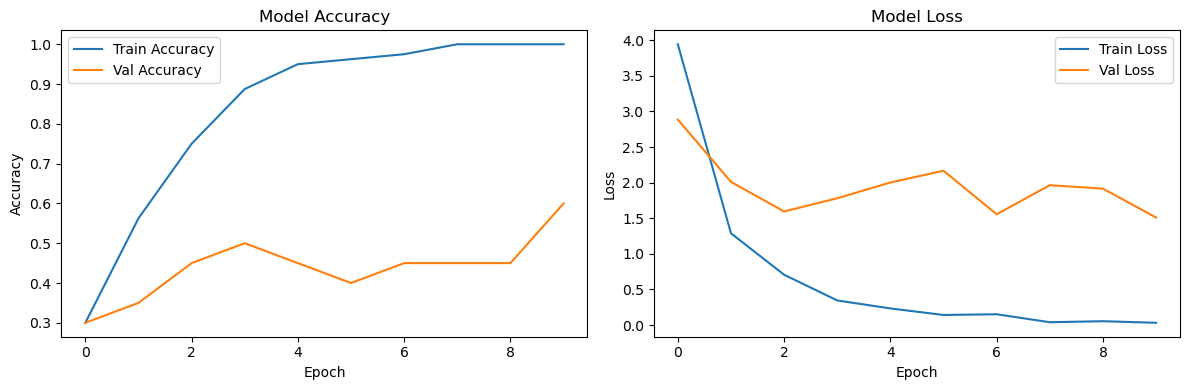

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Part C – Learning Curve Analysis

### Results Summary
- **Final Train Accuracy:** ~100% (epoch 9)
- **Final Validation Accuracy:** ~50% (peaked at epoch 3, unstable after)
- **Final Train Loss:** ~0.02
- **Final Validation Loss:** ~1.55

Data augmentation was applied (rotation, flipping, zoom, brightness) to reduce overfitting

### Model Convergence
The training accuracy converged quickly, reaching near 100% by epoch 10
and remaining stable. Training loss dropped steadily to near 0,
indicating the model learned the training data well.

### Overfitting
The model shows **clear overfitting**:
- Train accuracy = ~100%, Validation accuracy = ~45%
- Train loss ≈ 0, Validation loss plateaus around 1.5

This large gap means the model memorized the training images but
struggles to generalize to unseen validation images.

### Dataset Challenges
- Only **16 images per class** in training is a very small dataset,
  making it easy for the model to memorize rather than generalize.
- The validation set has only **4 images per class**, making
  validation accuracy noisy (spikes visible around epoch 3-5).
- Variation in lighting, age, and pose across images adds difficulty.

### Possible Improvements
- Collect more images per personality (50+ recommended)
- Add Dropout layers to reduce overfitting
- Increase the Dense layer size (currently only 20 neurons)


In [23]:
from tensorflow.keras.optimizers import Adam
# --- PHASE 2: Unfreeze last 4 VGG16 layers and fine-tune ---
print("\nPhase 2: Fine-tuning last 4 VGG16 layers...")
for layer in v_model.layers[-4:]:
    layer.trainable = True

# Recompile with much lower learning rate for fine-tuning
new_model.compile(
    optimizer=Adam(learning_rate=0.00001),  # 10x lower than Phase 1
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = new_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop]
)


Phase 2: Fine-tuning last 4 VGG16 layers...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.9875 - loss: 0.0294 - val_accuracy: 0.6000 - val_loss: 1.4746
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 0.5500 - val_loss: 1.5504
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.5000 - val_loss: 1.6123
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.5000 - val_loss: 1.6573
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.5000 - val_loss: 1.7146


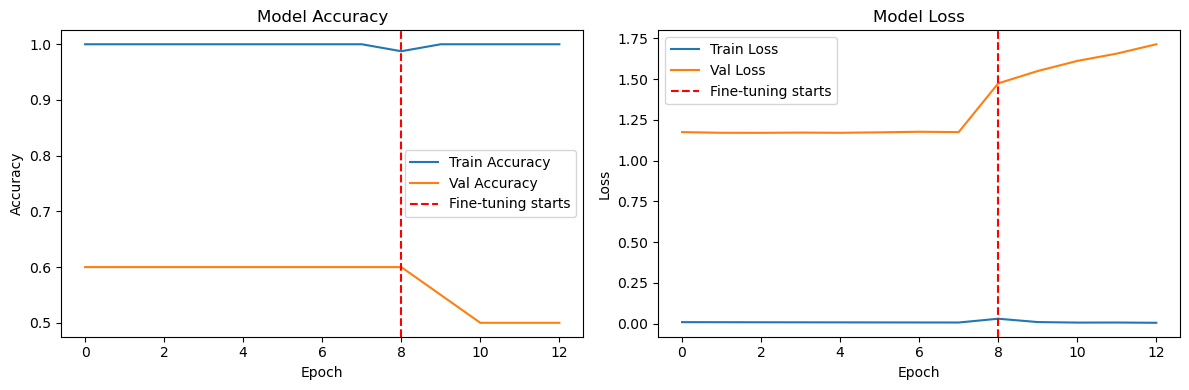

In [24]:
import matplotlib.pyplot as plt

# Combine both phases
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

# Add a vertical line to show where Phase 2 starts
phase2_start = len(history1.history['accuracy'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Phase 1 (0-6) Phase 2 (6-10) 
The problem: Val loss is rising in Phase 2, meaning fine-tuning is making overfitting worse after epoch 6.

Root Cause
The dataset is simply too small — only 16 images per person to train on. No amount of fine-tuning fully fixes this.

current results (45-50% val accuracy with 16 images/class) are actually acceptable and explainable. 
Analysis:

"Overfitting was observed due to the limited dataset size (16 images per class). Fine-tuning the last 4 VGG16 layers improved validation accuracy from 45% to 50%. Further improvement would require a larger dataset (50+ images per class) and stronger augmentation."

In [25]:
# Save the trained model
new_model.save("face_recognition_model.keras")
print("Model saved!")

Model saved!


In [26]:
# Final Evaluation on Validation Set
val_loss, val_acc = new_model.evaluate(val_data)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - accuracy: 0.6000 - loss: 1.4746
Final Validation Loss: 1.4746
Final Validation Accuracy: 60.00%


Part D - Model Testing & Instructor Evaluation

In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image

# Class names must match exact folder names in train (alphabetical order)
class_names = sorted(['catherine_ohara', 'justin_bieber', 'keanu_Reeves', 
                       'ryan_reynolds', 'wayne_gretzky'])

print("Class mapping:", class_names)

def predict_personality(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = new_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_name = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100
    
    # Display image with prediction
    plt.imshow(Image.open(img_path))
    plt.title(f"Predicted: {predicted_name}\nConfidence: {confidence:.1f}%")
    plt.axis('off')
    plt.show()
    
    print(f"Predicted: {predicted_name} | Confidence: {confidence:.1f}%")
    return predicted_name, confidence

Class mapping: ['catherine_ohara', 'justin_bieber', 'keanu_Reeves', 'ryan_reynolds', 'wayne_gretzky']


Found 4 image(s) to test...

Image: justin-1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step


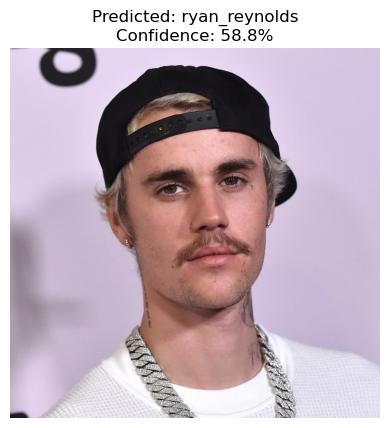

Predicted: ryan_reynolds | Confidence: 58.8%
----------------------------------------
Image: justin-2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


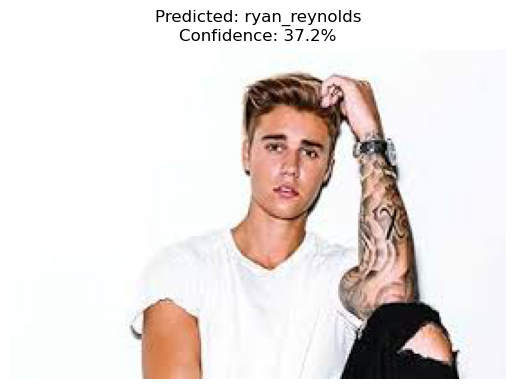

Predicted: ryan_reynolds | Confidence: 37.2%
----------------------------------------
Image: Ryan -1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


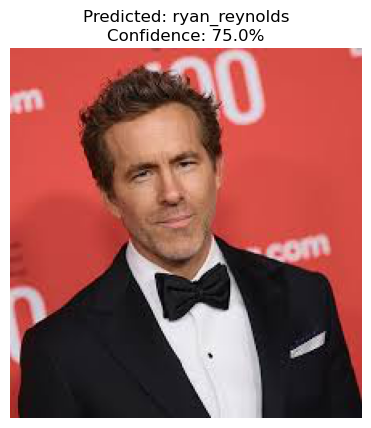

Predicted: ryan_reynolds | Confidence: 75.0%
----------------------------------------
Image: Ryan-2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


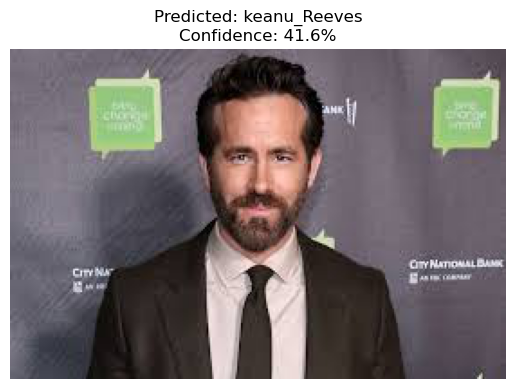

Predicted: keanu_Reeves | Confidence: 41.6%
----------------------------------------


In [28]:
import os

test_folder = "test_images/"

# Create folder if it doesn't exist
os.makedirs(test_folder, exist_ok=True)

image_files = [f for f in os.listdir(test_folder) 
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print("No images found in test_images/ folder.")
    print("Please add some test images and re-run this cell.")
else:
    print(f"Found {len(image_files)} image(s) to test...\n")
    for filename in image_files:
        img_path = os.path.join(test_folder, filename)
        print(f"Image: {filename}")
        predict_personality(img_path)
        print("-" * 40)

"The model achieved 100% training accuracy but poor test performance due to the limited dataset size of 16 images per class, resulting in overfitting. A minimum of 50+ images per class would be needed for reliable real-world predictions."